# **2024(R6)年度 機械学習**
# **第5週　線形/非線形モデルによる回帰**
## 線形回帰モデル(Linear Regression Model)
## 線形サポートベクトルマシン(ハードマージン・ソフトマージン)(Hard/Soft Margin Linear Support Vector Machine; SVM)
## 多層パーセプトロン(Multi-Layer Perceptron; MLP)
©️小林 邦和＠愛知県立大学 情報科学部  
Date: November 7, 2023

# **準備**

## 警告の非表示(必要に応じて実行，Google Colabでは不要)

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Google Driveのマウント(必要に応じて実行)

In [2]:
if str(get_ipython()).startswith("<google.colab."):
    from google.colab import drive
    drive.mount('/content/drive')

## rootディレクトリの指定(必要に応じてディレクトリ名を変更の上，実行)

In [3]:
if str(get_ipython()).startswith("<google.colab."):
    root_dir = '/content/drive/My Drive/Colab Notebooks/Machine_Learning_2023/' # 要変更
else:
    root_dir = './'

## 日本語化Matplotlib(必要に応じて実行)

In [4]:
# if str(get_ipython()).startswith("<google.colab."):
#     !pip install japanize-matplotlib

## 各種ライブラリの読み込み

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# グラフ表示で日本語を使う場合，以下2行は必須
# import japanize_matplotlib
# japanize_matplotlib.japanize()

## フラグ設定

In [6]:
# 使用する回帰モデルのコメントを外し，使用しないものはコメントアウト
model_flag = 0 # 線形回帰モデル(最小二乗法によるパラメータ推定)
# model_flag = 1 # ハードマージン線形SVR
# model_flag = 2 # ソフトマージン線形SVR
# model_flag = 3 # 非線形SVR(カーネル:RBF)
# model_flag = 4 # 非線形SVR(カーネル:多項式関数)
# model_flag = 5 # 非線形SVR(カーネル:シグモイド関数)
# model_flag = 6 # 多層パーセプトロン(活性化関数:恒等関数)
# model_flag = 7 # 多層パーセプトロン(活性化関数:シグモイド関数)
# model_flag = 8 # 多層パーセプトロン(活性化関数:双曲線正接関数(tanh))
# model_flag = 9 # 多層パーセプトロン(活性化関数:正規化線形関数(ReLU))

match model_flag:
    case 1: # ハードマージン線形SVM
        kernel = 'linear'
        C=100
    case 2: # ソフトマージン線形SVM
        kernel = 'linear'
        C=1
    case 3: # 非線形SVM(カーネル:RBF)
        kernel='rbf'
        C=100
    case 4: # 非線形SVM(カーネル:多項式関数)
        kernel='poly'
        C=100
    case 5: # 非線形SVM(カーネル:シグモイド関数)
        kernel='sigmoid'
        C=100

match model_flag:
    case 6: # 多層パーセプトロン(活性化関数:恒等関数)
        a_func = 'identity'
    case 7: # 多層パーセプトロン(活性化関数:シグモイド関数)
        a_func = 'logistic'
    case 8: # 多層パーセプトロン(活性化関数:双曲線正接関数(tanh))
        a_func = 'tanh'
    case 9: # 多層パーセプトロン(活性化関数:正規化線形関数(ReLU))
        a_func = 'relu'

match model_flag:
    case 6 | 7 | 8 | 9:
        # 使用するMLPモデルの中間層ユニット数のコメントを外し，使用しないものはコメントアウト
        # hidden_layer_sizes=(10,)
        hidden_layer_sizes=(20,)
        # hidden_layer_sizes=(50,)
        # hidden_layer_sizes=(20,10)
        # hidden_layer_sizes=(50,20)

# **データの準備**

## **回帰データセットの生成**
### **make_regression**
引数
*   n_samples：データの個数
*   n_features：特徴量の数(N)
*   noise：ガウスノイズの標準偏差
*   random_state：乱数生成のシード値(同じ値の設定で再現性の確保)

戻り値
*   入力データ(n_samples x n_features)
*   出力データ(n_samples)


## **人工的データの生成**
特徴量が1次元，標準偏差が10の100個のデータセット

In [7]:
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=1,
    # n_features=2,
    noise=10,
    # noise=30,
    random_state=3)

# 特徴量（X）でデータフレームを作成し，（y）をClassの列として追加
df = pd.DataFrame(X)
df.rename(columns={0: "X"}, inplace=True)

df["Y"] = y
df.head()

,X,Y
0,0.150617,8.013899
1,-0.888657,-25.792846
2,-1.860890,-79.826582
3,0.152946,-3.008826
4,0.899338,19.862157


# **データの分析**

## **散布図**
入力Xを横軸に，出力Yを縦軸にして散布図の描画

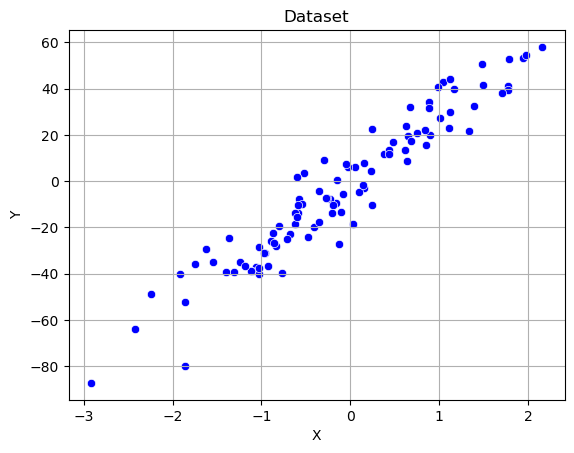

In [8]:
sns.scatterplot(x="X", y="Y", color="b", data=df)
plt.title("Dataset")
#plt.title("データセット")
plt.grid()
plt.show()

# 3Dグラフの描画
# fig = plt.figure(figsize=(5, 5))
# ax = fig.add_subplot(projection='3d')
# ax.scatter(df["X1"], df["X2"], df["Y"], color="b")
# plt.title("Dataset")
# ax.set_xlabel("X1")
# ax.set_ylabel("X2")
# ax.set_zlabel("Y")
# plt.show()

# **データの分割(訓練用とテスト用)**
### **train_test_split**
引数
*   test_size：テストデータのサイズ指定(0〜1.0)
*   train_size：訓練データのサイズ指定(0〜1.0)
*   random_state：乱数生成のシード値

戻り値
*   X_train：訓練用入力データ
*   y_train：訓練用出力データ
*   X_test：テスト用入力データ
*   y_test：テスト用出力データ

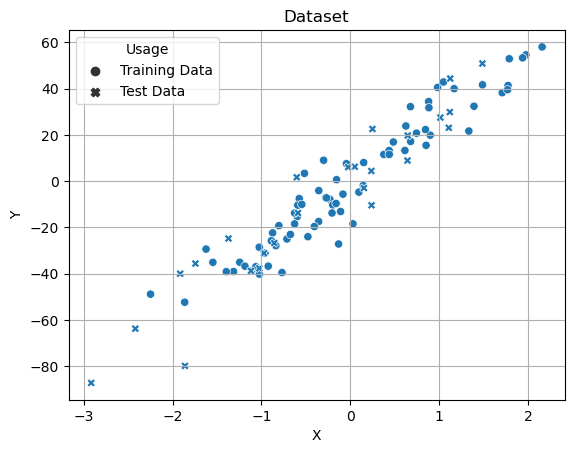

In [9]:
# 訓練データとテストデータへ分割
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# 訓練用の特徴量(X_train)でデータフレームを作成し，クラス(y_train)をClassの列として追加
df_train = pd.DataFrame(X_train)
df_train.rename(columns={0: "X"}, inplace=True)
df_train["Y"] = y_train
df_train["Usage"] = "Training Data"

# テスト用の特徴量(X_test)でデータフレームを作成し，クラス(y_test)をClassの列として追加
df_test = pd.DataFrame(X_test)
df_test.rename(columns={0: "X"}, inplace=True)
df_test["Y"] = y_test
df_test["Usage"] = "Test Data"

# 訓練用とテスト用のデータを結合
df = pd.concat([df_train, df_test])

# クラス0は青，クラス1は橙，訓練用はO，テスト用はXで散布図を描画
sns.scatterplot(x="X", y="Y", style="Usage", data=df)
plt.title("Dataset")
plt.grid()
plt.show()

# **モデルの学習**
## **線形/非線形回帰モデル**
### **使用モデル一覧**
*   線形回帰モデル(最小二乗法推定)
*   ハードマージン線形SVR
*   ソフトマージン線形SVR
*   非線形SVR(カーネル: RBF)
*   非線形SVR(カーネル: 多項式関数)
*   非線形SVR(カーネル: シグモイド関数)
*   多層パーセプトロン

### **LinearRegression** 線形回帰のクラス  

### **SVR** サポートベクトル回帰のクラス  
*   kernel：カーネル関数  
    線形SVMの場合，‘linear’を指定  
    非線形SVMの場合，以下を指定
    *   動径基底関数: ‘rbf’
    *   多項式関数: ‘poly’
    *   シグモイド関数: ‘sigmoid’
*   C：正規化係数

### **MLPRegressor** 多層パーセプトロンのクラス
引数
*   hidden_layer_sizes：中間層のユニット数と層数  
    例1: (20,10)の場合，中間層2層構造で第1と第2中間層のユニット数がそれぞれ20個，10個  
    例2: (10,20,10)の場合，中間層3層構造で第1，第2，第3中間層のユニット数がそれぞれ10個，20個，10個
*   activation：ユニットの活性化関数
    *   恒等写像‘identity’
    *   シグモイド関数‘logistic’
    *   双曲線正接関数‘tanh’
    *   正規化線形関数‘relu’

### **fit** モデルの訓練のための関数(メソッド)  
引数
*   X：入力データ
*   y：出力データ

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# 各種回帰モデルによる学習モデルの作成
match model_flag:
    case 0: # 線形回帰モデル(最小二乗法推定)
        model = LinearRegression()
        print("線形回帰モデル(最小二乗法推定)")
    case 1 | 2 | 3 | 4 | 5: # SVM
        model = SVR(kernel=kernel, C=C)
    case 6 | 7 | 8 | 9: # 多層パーセプトロン
        model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, activation=a_func)

# 訓練データを用いた学習
model.fit(X_train, y_train)

線形回帰モデル(最小二乗法推定)


LinearRegression()

# **学習済みモデルのテスト**
### **predict** 学習済モデルのテストのための関数(メソッド)
引数
*   y：出力データ

戻り値
*   予測値

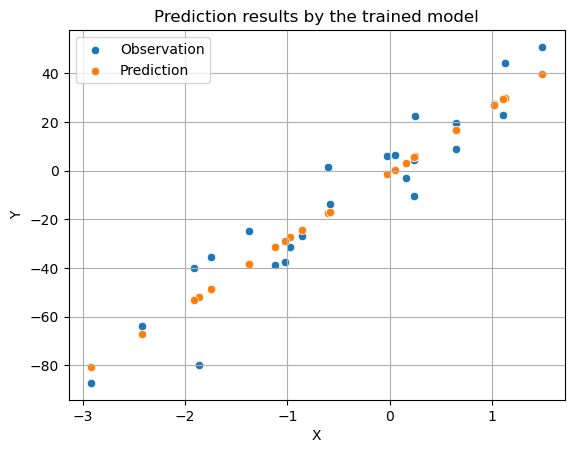

In [11]:

# テストデータを用いた予測
pred_test = model.predict(X_test)

# クラスの予測結果(pred_test)をPredictionの列として追加
df_test["Prediction"] = pred_test

# 正解のクラス0は青，クラス1は橙，予測のクラス0はO，クラス1はXで散布図を描画
sns.scatterplot(x="X", y="Y", data=df_test)
sns.scatterplot(x="X", y="Prediction", data=df_test)
plt.title("Prediction results by the trained model")
plt.legend(labels=["Observation", "Prediction"])
plt.grid()
plt.show()

# **モデルの性能評価**

## **決定係数$R^2$の計算**
### **r2_score**
引数
*   X：テスト用入力データ
*   y：テスト用出力データ

戻り値
*   決定係数

In [12]:
from sklearn.metrics import r2_score

# 決定係数R^2の計算(テストデータ)
score = r2_score(y_test, pred_test)
print("決定係数 = {0:6.3f}".format(score))

決定係数 =  0.906


## **平均絶対誤差(MAE)の計算**
### **mean_absolute_error**
引数
*   X：テスト用入力データ
*   y：テスト用出力データ

戻り値
*   MAE

In [13]:
from sklearn.metrics import mean_absolute_error

# MAEの計算(テストデータ)
score = mean_absolute_error(y_test, pred_test)
print("MAE = {0:6.2f}".format(score))

MAE =   8.77


## **平均平方二乗誤差(RMSE)の計算**
### **mean_squared_error**
引数
*   X：テスト用入力データ
*   y：テスト用出力データ
*   squared：Falseの場合，RMSEの計算(Trueの場合，MSEの計算)

戻り値
*   RMSE

In [14]:
from sklearn.metrics import mean_squared_error

# RMSEの計算(テストデータ)
score = mean_squared_error(y_test, pred_test, squared=False)
print("RMSE = {0:6.2f}".format(score))

RMSE =  10.95


## **回帰直線/曲線の描画**

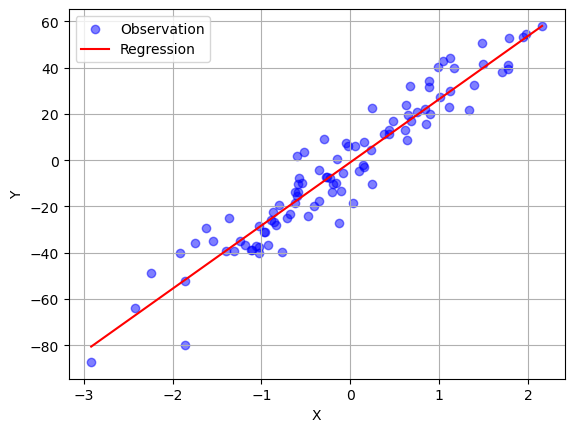

In [15]:
plt.scatter(X, y, color="b", alpha=0.5)
n_data = 1000 # 横軸のデータ数
XX = np.linspace(np.min(X), np.max(X), n_data).reshape(n_data, 1)
plt.plot(XX, model.predict(XX), color="r")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(labels=["Observation", "Regression"])
plt.grid()
plt.show()